# CNN Experiment Result Aggregation
각 실험 노트북이 저장한 JSON 결과를 모아서 loss curve와 test accuracy bar chart를 생성한다.


In [1]:
import json
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULT_DIR = '/content/drive/MyDrive/experiment_results'
except ModuleNotFoundError:
    RESULT_DIR = './experiment_results'

result_paths = sorted(glob.glob(os.path.join(RESULT_DIR, '*.json')))
print('Result directory:', RESULT_DIR)
print('Result files:', len(result_paths))

results = []
for path in result_paths:
    with open(path, 'r', encoding='utf-8') as f:
        item = json.load(f)
    item['result_path'] = path
    results.append(item)

if not results:
    raise FileNotFoundError('No result JSON files found. Run each experiment notebook first.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Result directory: /content/drive/MyDrive/experiment_results
Result files: 11


## 1. 결과 요약 테이블


In [2]:
summary_df = pd.DataFrame([
    {
        'experiment_name': r['experiment_name'],
        'test_accuracy': r['test_accuracy'],
        'parameter_count': r['parameter_count'],
        'training_time_sec': r['training_time_sec'],
        'fc_input': r['fc_input'],
    }
    for r in results
]).sort_values('test_accuracy', ascending=False).reset_index(drop=True)

summary_df


,experiment_name,test_accuracy,parameter_count,training_time_sec,fc_input
0,3 Conv Layers,99.40,1255682,265.852303,1152
1,Mixed Kernel 5-3-3 + 3 Conv Layers,99.38,1256194,293.628811,1152
2,FC Hidden 512,99.37,1630090,276.417397,3136
3,FC Hidden 256,99.23,824458,168.558514,3136
4,"Baseline (32,64)",99.23,3165826,129.871644,3136
5,"Small Filters (16,32)",99.21,1583810,599.177722,1568
6,4 Conv Layers,99.20,654850,294.502284,256
7,No Padding,99.17,1629826,594.759563,1600
8,"Large Filters (64,128)",99.16,6357506,288.077318,6272
9,Kernel 5x5,99.13,3199106,256.154177,3136


## 2. Test Accuracy Bar Chart


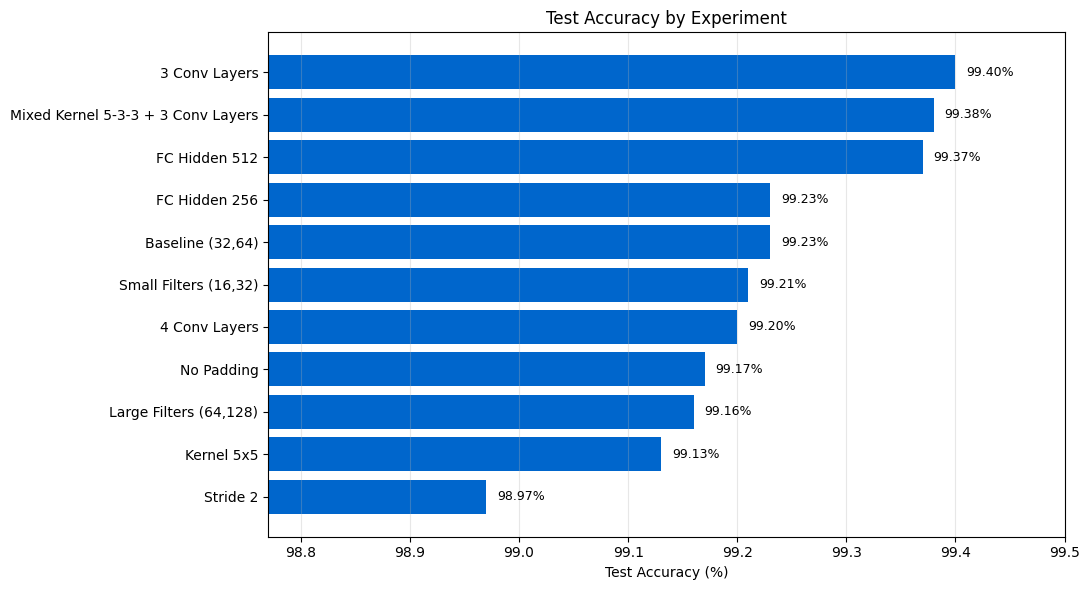

In [3]:
plot_df = summary_df.sort_values('test_accuracy', ascending=True)

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df['experiment_name'], plot_df['test_accuracy'], color='#0066CC')
plt.title('Test Accuracy by Experiment')
plt.xlabel('Test Accuracy (%)')
plt.xlim(max(0, plot_df['test_accuracy'].min() - 0.2), min(100, plot_df['test_accuracy'].max() + 0.1))
plt.grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, plot_df['test_accuracy']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{acc:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Epoch별 Loss Curve 비교


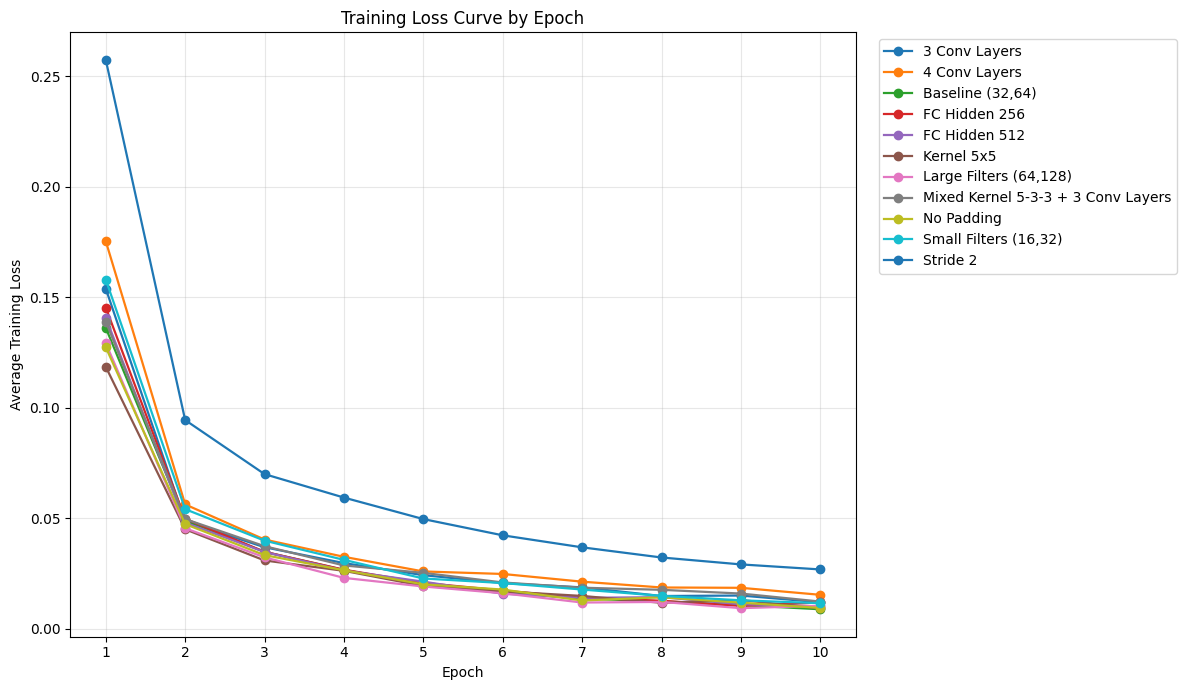

In [4]:
plt.figure(figsize=(12, 7))

for r in results:
    losses = r['epoch_loss_history']
    epochs = range(1, len(losses) + 1)
    plt.plot(epochs, losses, marker='o', linewidth=1.6, label=r['experiment_name'])

plt.title('Training Loss Curve by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.xticks(range(1, max(len(r['epoch_loss_history']) for r in results) + 1))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Parameters vs Accuracy Scatter Plot


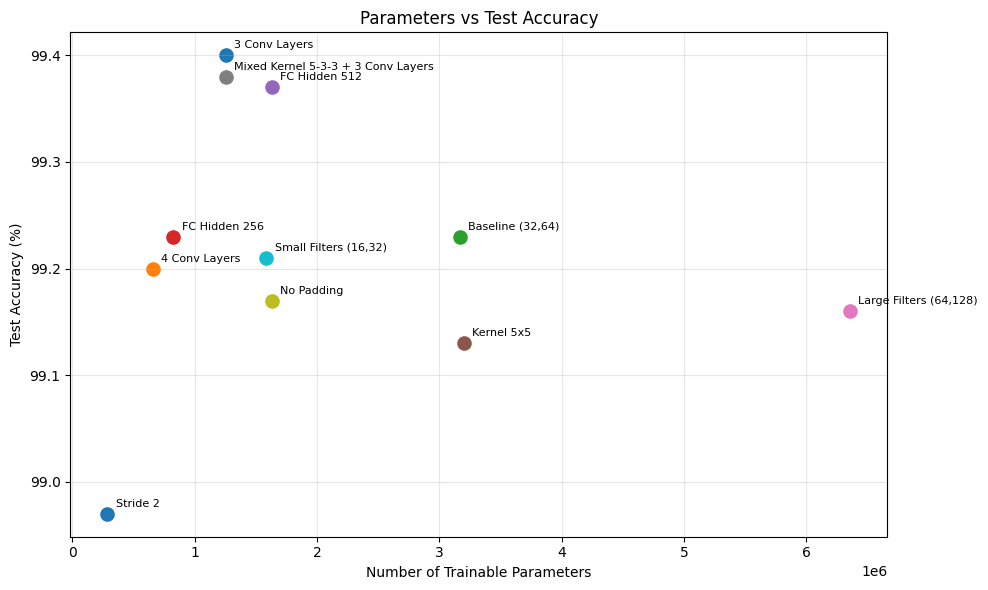

In [5]:
plt.figure(figsize=(10, 6))

for r in results:
    plt.scatter(r['parameter_count'], r['test_accuracy'], s=90)
    plt.annotate(r['experiment_name'],
                 (r['parameter_count'], r['test_accuracy']),
                 textcoords='offset points', xytext=(6, 5), fontsize=8)

plt.title('Parameters vs Test Accuracy')
plt.xlabel('Number of Trainable Parameters')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
